In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os ; import re
from astropy.convolution import Gaussian1DKernel, convolve
from pathlib import Path
from lib_QMout import *
from scipy.interpolate import CubicSpline
from sympy.physics.wigner import wigner_3j
import math ; from collections import defaultdict

In [2]:
npnts = 10001
nvib = 36
nJ = 81

In [ ]:
#-------------------------------------------------------------------------------#
# EXTRAER AUTOFUNCIONES VIBRACIONALES
#-------------------------------------------------------------------------------#
def is_head_eigenvib(line:str) -> bool:
    """
    Detecta la linea que marca el comienzo de 
    una nueva autofunción de un nivel vibracional
    Formato: 1 0.0000 1 0 X 3Sigmam -> 
    -------> Indice Energia Estado NVib Nombre Estado
    """

    s = line.strip()
    if not s:
        return False
    
    parts = s.split()
    #Si no tiene más de 2 campos
    if len(parts) < 2:
        return False
    
    #POR SI ACASOS
    #Si el primer campo no es un entero
    if not re.fullmatch(r"[+-]?\d+", parts[0]):
        return False
    
    #Si el segundo campo no es un valor decimal
    if not re.fullmatch(r"[+-]?(\d+(\.\d*)?|\.\d+)([Ee][+-]?\d+)?", parts[1]):
        return False
    
    return True

#-------------------------------------------------------------------------------#
#Parsing Vibrational Eigenfunctions
#-------------------------------------------------------------------------------#

def parse_duo_vib_einfun(fname:str, npoints: int, nvib: int):
    """
    Parsea el archivo de autofunciones de vibración de DUO
    """
    f = open(fname, 'r')
    lines = f.readlines()

    vibmat = np.zeros((npoints,nvib))
    evect = np.zeros((nvib))
    ncurrpoint = 0 ; ncurrvib = 0
    for i,line in enumerate(lines):
        if is_head_eigenvib(line):
            ncurrpoint = 0
            ncurrvib = int(line.split()[3])
            evect[ncurrvib] = float(line.split()[1])
        elif "End of contracted basis" in line:
            break
        else:
            vibmat[ncurrpoint,ncurrvib] = float(line)
            ncurrpoint += 1

    return vibmat

#-------------------------------------------------------------------------------#
# Reading Dyson Matrix
#-------------------------------------------------------------------------------#

def dyson_mat(fname:str):
    dysvals = np.loadtxt(fname, dtype=np.float64)
    rvals = dysvals[:,0]; dys_N_C1 = dysvals[:,1] ; dys_N_C2 = dysvals[:,2]
    dysmat_N_C1 = np.zeros((dysvals.shape[0],dysvals.shape[0]))
    dysmat_N_C2 = np.zeros((dysvals.shape[0],dysvals.shape[0]))

    for i in range(dysvals.shape[0]):
            dysmat_N_C1[i][i] = dys_N_C1[i]*0.393456
            dysmat_N_C2[i][i] = dys_N_C2[i]*0.393456

    return rvals,dysmat_N_C1, dysmat_N_C2

#-------------------------------------------------------------------------------#
# Calculating BraKet
#-------------------------------------------------------------------------------#

def bra_ket(vib_ini, vib_fin, dymat):
    intensity = (vib_fin.T @ (dymat @ vib_ini))
    return intensity
def bk_Coeff(vib_ini, vib_fin, dymat, coef_ini, coef_fin):
    if np.array(coef_ini).shape[0] == 0 or np.array(coef_fin).shape[0] == 0:
        return bra_ket(vib_ini, vib_fin, dymat)
    
    coeffs = np.dot(np.array(coef_fin).conj(), np.array(coef_ini))
    intensity = (vib_fin.T @ (dymat @ vib_ini))
    intensity = intensity * coeffs
    return intensity

#-------------------------------------------------------------------------------#
#Honl-London factors
#-------------------------------------------------------------------------------#

def honl_london_factors(Ji,dJ):
    """
    Calculate Honl-London factors
    """
    den = 2*Ji + 1
    if dJ == -1: 
        return Ji/den if Ji > 0 else 0.0
    if dJ == 0:
        return 1.0/den
    if dJ == 1:
        return (Ji+1)/den

    return 0.0

#-------------------------------------------------------------------------------#
# Get normalization factor Q(T) complete rovibrational levels including Projs
#-------------------------------------------------------------------------------#

def rovibOm_normf(T, Jener, ZPE, Estt, numvib:int, numJ:int, Projs:int, index):

    Eh_to_cm = 219474.6
    kb = 3.166811563e-6  # Eh/K

    # calcular Emin global coherente
    Emin = 1e99
    for i in range(numvib):
        for j in range(numJ):
            for k in range(Projs):
                Ei = (Jener[i,j,k] + ZPE)/Eh_to_cm + Estt
                if Ei < Emin:
                    Emin = Ei

    # construir Q(T)
    Q = 0.0
    for i in range(numvib):
        for j in range(numJ):
            for k in range(Projs):
                Ei = (Jener[i,j,k] + ZPE)/Eh_to_cm + Estt
                Ei_rel = Ei - Emin
                jval=index[i][j][k][1]
                Q += (2*jval+1) * np.exp(-Ei_rel/(kb*T))

    return Q

#-------------------------------------------------------------------------------#
# Get normalization factor Q(T) rotational levels including Projs
#-------------------------------------------------------------------------------#

def rot_normf(T, Jener, ZPE, Estt, numvib:int, numJ:int, Projs:int, index):

    Eh_to_cm = 219474.6
    kb = 3.166811563e-6  # Eh/K

    # calcular Emin global coherente
    Emin = 1e99
    for i in range(numvib):
        for j in range(numJ):
            for k in range(Projs):
                Ei = (Jener[i,j,k] + ZPE)/Eh_to_cm + Estt
                if Ei < Emin:
                    Emin = Ei

    # construir Q(T)
    Q = np.zeros((numvib))
    for i in range(numvib):
        for j in range(numJ):
            for k in range(Projs):
                Ei = (Jener[i,j,k] + ZPE)/Eh_to_cm + Estt
                Ei_rel = Ei - Emin
                jval=index[i][j][k][1]
                Q[i] += (2*jval+1) * np.exp(-Ei_rel/(kb*T))

    return Q

#-------------------------------------------------------------------------------#
# Get normalization factor Q(T) vibrational levels including Projs
#-------------------------------------------------------------------------------#

def vib_normf(T, Jener, ZPE, Estt, numvib:int, numJ:int, Projs:int, index):

    Eh_to_cm = 219474.6
    kb = 3.166811563e-6  # Eh/K

    # calcular Emin global coherente
    Emin = 1e99
    for i in range(numvib):
        Ei = (Jener[i][0][1] + ZPE)/Eh_to_cm + Estt
        if Ei < Emin:
            Emin = Ei

    # construir Q(T)
    Q = 0.0
    for i in range(numvib):
        Ei = (Jener[i][0][1] + ZPE)/Eh_to_cm + Estt
        Ei_rel = Ei - Emin
        Q += np.exp(-Ei_rel/(kb*T))

    return Q

#-------------------------------------------------------------------------------#
#Get Evals by Vib, J, Omega, Sigma, Lambda 
#-------------------------------------------------------------------------------#

def getJvals_compInd(fname:str, nvib: int, nj: int, mult: int, nLambda:int):
    f = open(fname, 'r')
    lines = f.readlines()

    S=(mult-1)/2
    nSigma = mult
    parity = 2
    jn = 0
    for i,line in enumerate(lines):
        if i == 0:
            if nLambda == 0:
                nOmega = mult
            else:
                nOmega = (nLambda+1) * mult
            nLind = nLambda + 1 
            Jvals = np.zeros((nvib,nj,nOmega))
            index_list = np.zeros((nvib,nj,nOmega,7))
            key_dict = np.zeros((nvib,nj,nOmega,6))

        parts = line.split()
        vibn = int(parts[4])
        jn = int(round(float(parts[0])))

        #Getting indexes for J projections
        mval = float(parts[8])
        midx = int(round(mval+S))

        if nLambda == 0:
            nL = 0
        else:
            if float(parts[5]) == -nLambda:
                nL = 0
            else:
                nL = 1
        nS = int(round(float(parts[7])+S))

        pm = parts[9]
        if pm == '-':
            p = 1
        else:
            p = 0
        
        if vibn <= 35:
            # print(i,vibn,float(parts[0]),float(parts[8]),float(parts[7]),float(parts[5]),p)
            Jvals[vibn,jn,midx] = float(parts[2])
            index_list[vibn,jn,midx,:] = vibn,float(parts[0]),float(parts[8]),float(parts[7]),float(parts[5]),p,int(parts[1]) # [0] Vib, [1] J, [2] m, [3] S, [4] Lambda, [5] Parity, [6] Index
            key_dict[vibn,jn,midx,:] = float(parts[0]),float(parts[8]),float(parts[7]),float(parts[5]),p,int(parts[1]) # [1] J, [2] m, [3] S, [4] Lambda, [5] Parity, [6] Index

    return Jvals,nOmega,index_list,key_dict

#-------------------------------------------------------------------------------#
#Wigner 3j values
#-------------------------------------------------------------------------------#
def coeff_wig3j(Ji,Jf,Omi,Omf,djlist,djval):
    
    s=0.0
    for dJ in djlist:
        # val = wigner_3j(Jf,DJ,Ji,-Omf,dJ,Omi)
        val = wigner_3j(Jf,1.5,Ji,-Omf,dJ,Omi)
        s += float(val)

    return (2*Jf+1)*s

#-------------------------------------------------------------------------------#
#Kronecker delta
#-------------------------------------------------------------------------------#

def kronecker_delta(i,j):
    if i == j:
        return 1.0
    else:
        return 0.0

#-------------------------------------------------------------------------------#
#Factorial
#-------------------------------------------------------------------------------#
def fact(n):
    f=1
    if n%1 == 0:
        n=int(n)
    else:
        print(n)
        return 0
    for i in range(n):
        f=f*(i+1)
    return f 

#-------------------------------------------------------------------------------#
#Wigner 3j explicit expression
#-------------------------------------------------------------------------------#
def W3_exp(J1,J2,J3,m1,m2,m3):
    K=max(0,J2-J3-m1,J1-J3+m2)
    if K%1 != 0:
        return 0.0
    else: 
        K=int(K)
    N=min(J1+J2-J3,J1-m1,J2+m2)
    if N%1 != 0:
        return 0.0
    else: 
        N=int(N)
    
    deltaK = kronecker_delta(m1+m2+m3,0)
    m1pf = (-1)**(J1-J2-m3)

    #First element
    J1MJ2mJ3 = fact(J1+J2-J3)
    J1mJ2MJ3 = fact(J1-J2+J3)
    mJ1MJ2MJ3 = fact(-J1+J2+J3)
    J1MJ2MJ3M1 = fact(J1+J2+J3+1)
    first_root = math.sqrt((J1MJ2mJ3*J1mJ2MJ3*mJ1MJ2MJ3)/J1MJ2MJ3M1)

    #Second element
    J1mO1 = fact(J1-m1)
    J1MO1 = fact(J1+m1)
    J2mO2 = fact(J2-m2)
    J2MO2 = fact(J2+m2)
    J3mO3 = fact(J3-m3)
    J3MO3 = fact(J3+m3)
    second_root = math.isqrt(J1mO1*J1MO1*J2mO2*J2MO2*J3mO3*J3MO3)

    #Third element
    third_root = 0.0
    for k in range(K,N+1):
        m1pk = (-1)**k
        kf = fact(k)
        J1MJ2mJ3mk = fact(J1+J2-J3-k)
        J1mO1mk = fact(J1-m1-k)
        J2MO2mk = fact(J2+m2-k)
        J3mJ1MO1Mk = fact(J3-J2+m1+k)
        J3mJ1mO2Mk = fact(J3-J1-m2+k)
        coeff = m1pk/(kf*J1MJ2mJ3mk*J1mO1mk*J2MO2mk*J3mJ1MO1Mk*J3mJ1mO2Mk)
        third_root += coeff

    return deltaK*m1pf*first_root*second_root*third_root

#-------------------------------------------------------------------------------#
#Make intensity matrix including Omega values
#-------------------------------------------------------------------------------#

def int_Omdist(PHener,PHMener,dysmat,PHvibs,PHMvibs,mask,Temp,
                ZPEPH,ZPEPHM,PHsttsE,PHMsttsE,DJ:int,
                numvibPH:int,numvibPHM:int,numJPH:int,numJPHM:int,
                numOmPH:int,numOmPHM:int,indexPH,indexPHM):

    """
    Make the intensity matrix
    """
    Eh_to_cm = 219474.6
    dysmat = dysmat[mask] ; dysmat = dysmat[:,mask]
    relInt = np.zeros((numvibPH,numvibPHM,numJPH,numJPHM,numOmPH,numOmPHM))
    evals = np.zeros((numvibPH,numvibPHM,numJPH,numJPHM,numOmPH,numOmPHM))

    normfPH = rovibOm_normf(Temp,PHener,ZPEPH,PHsttsE,numvibPH,numJPH,numOmPH,indexPH)
    normfPHM = rovibOm_normf(Temp,PHMener,ZPEPHM,PHMsttsE,numvibPHM,numJPHM,numOmPHM,indexPHM)

    djlist = []
    initdj = -DJ
    for i in range(int(initdj+DJ),int(DJ+DJ)+1,1):
        djval = i -DJ
        djlist.append(djval)

    print(djlist)
    
    for i in range(numvibPH):
        for j in range(numvibPHM):

            PHvibsvn = PHvibs[:,i] ; PHvibsvn = PHvibsvn[mask]
            PHMvibsvn = PHMvibs[:,j] ; PHMvibsvn = PHMvibsvn[mask]
            bk_val = bra_ket(PHvibsvn,PHMvibsvn,dysmat)

            for k in range(numJPH):
                for l in range(numJPHM):
                    for m in range(numOmPH):
                        PHsumOmega = (PHener[i,k,m]+ZPEPH)/Eh_to_cm
                        eboltz = PHsumOmega - ((np.min(PHener[:,:,:]) + ZPEPH)/Eh_to_cm)
                        Jival=indexPH[i,k,m,1]
                        degJi = ((2*Jival+1)*np.exp(-eboltz/(3.166811563*10**(-6)*Temp)))/normfPH
                        PHsumOmega += PHsttsE

                        for n in range(numOmPHM):

                            PHMsumOmega = ((PHMener[j,l,n])+ZPEPHM)/Eh_to_cm
                            eboltz = PHMsumOmega - (((np.min(PHMener[:,:,:])+ZPEPHM)/Eh_to_cm))
                            PHMsumOmega += PHMsttsE

                            diff = abs(PHsumOmega - PHMsumOmega)

                            Jfval=indexPHM[j,l,n,1]

                            djval = Jfval - Jival
                            rotcoeff = 0.0
                            for dj in djlist:
                                rotcoeff += W3_exp(Jfval,DJ,Jival,indexPHM[j,l,n,2],dj,indexPH[i,k,m,2])
                            # relInt[i,j,k,l,m,n] = degJi*diff*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            relInt[i,j,k,l,m,n] = degJi*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            evals[i,j,k,l,m,n] = diff
    return evals,relInt

#-------------------------------------------------------------------------------#
#Make intensity matrix including Rotational coeffs
#-------------------------------------------------------------------------------#

def int_Coeffs(PHener,PHMener,dysmat,PHvibs,PHMvibs,mask,Temp,
                ZPEPH,ZPEPHM,PHsttsE,PHMsttsE,DJ:int,
                numvibPH:int,numvibPHM:int,numJPH:int,numJPHM:int,
                numOmPH:int,numOmPHM:int,indexPH,indexPHM,
                keyPH,keyPHM,coefPH,coefPHM):

    """
    Make the intensity matrix
    """
    Eh_to_cm = 219474.6
    dysmat = dysmat[mask] ; dysmat = dysmat[:,mask]
    relInt = np.zeros((numvibPH,numvibPHM,numJPH,numJPHM,numOmPH,numOmPHM))
    evals = np.zeros((numvibPH,numvibPHM,numJPH,numJPHM,numOmPH,numOmPHM))

    normfPH = rovibOm_normf(Temp,PHener,ZPEPH,PHsttsE,numvibPH,numJPH,numOmPH,indexPH)
    normfPHM = rovibOm_normf(Temp,PHMener,ZPEPHM,PHMsttsE,numvibPHM,numJPHM,numOmPHM,indexPHM)

    djlist = []
    initdj = -DJ
    for i in range(int(initdj+DJ),int(DJ+DJ)+1,1):
        djval = i -DJ
        djlist.append(djval)
    
    print(djlist)

    for i in range(numvibPH):
        for j in range(numvibPHM):

            PHvibsvn = PHvibs[:,i] ; PHvibsvn = PHvibsvn[mask]
            PHMvibsvn = PHMvibs[:,j] ; PHMvibsvn = PHMvibsvn[mask]

            for k in range(numJPH):
                for l in range(numJPHM):
                    for m in range(numOmPH):
                        PHsumOmega = (PHener[i,k,m]+ZPEPH)/Eh_to_cm
                        eboltz = PHsumOmega - ((np.min(PHener[:,:,:]) + ZPEPH)/Eh_to_cm)
                        Jival=indexPH[i,k,m,1]
                        degJi = ((2*Jival+1)*np.exp(-eboltz/(3.166811563*10**(-6)*Temp)))/normfPH
                        PHsumOmega += PHsttsE

                        for n in range(numOmPHM):

                            keyPH_i = tuple(np.array(keyPH[i,k,m,:])) ; keyPHM_j = tuple(np.array(keyPHM[j,l,n,:]))
                            bk_val = bk_Coeff(PHvibsvn,PHMvibsvn,dysmat,coefPH[keyPH_i],coefPHM[keyPHM_j])

                            PHMsumOmega = ((PHMener[j,l,n])+ZPEPHM)/Eh_to_cm
                            eboltz = PHMsumOmega - (((np.min(PHMener[:,:,:])+ZPEPHM)/Eh_to_cm))
                            PHMsumOmega += PHMsttsE

                            diff = abs(PHsumOmega - PHMsumOmega)

                            Jfval=indexPHM[j,l,n,1]

                            djval = Jfval - Jival
                            rotcoeff = 0.0
                            for dj in djlist:
                                rotcoeff += W3_exp(Jfval,DJ,Jival,indexPHM[j,l,n,2],dj,indexPH[i,k,m,2])
                            # relInt[i,j,k,l,m,n] = degJi*diff*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            relInt[i,j,k,l,m,n] = degJi*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            # relInt[i,j,k,l,m,n] = degJi*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            evals[i,j,k,l,m,n] = diff
    return evals,relInt

#-------------------------------------------------------------------------------#
#Read coeff values according to index_list
#-------------------------------------------------------------------------------#

def read_coeff(filename):
    coef_dict = defaultdict(list)
    with open(filename) as f:
        for line in f:
            parts = line.split()

            if (parts[0]).isnumeric() == False: 
                continue
            else:
                vib = int(parts[5])
                J = float(parts[1])
                Om = float(parts[9])
                S = float(parts[8])
                L = float(parts[6])
                parity = int(parts[2])
                indx = int(parts[0])
                coeff = float(parts[3])

                key = (J,Om,S,L,parity,indx)
                coef_dict[key].append(coeff)

    for key in coef_dict:
        # print(coef_dict[key])
        coef_dict[key] = np.array(coef_dict[key])

    return coef_dict

#-------------------------------------------------------------------------------#
#Make intensity matrix including Rotational coeffs
#-------------------------------------------------------------------------------#

def intT_sep(PHener,PHMener,dysmat,PHvibs,PHMvibs,mask,Tvib,Trot,
                ZPEPH,ZPEPHM,PHsttsE,PHMsttsE,DJ:int,
                numvibPH:int,numvibPHM:int,numJPH:int,numJPHM:int,
                numOmPH:int,numOmPHM:int,indexPH,indexPHM,
                keyPH,keyPHM,coefPH,coefPHM):

    """
    Make the intensity matrix
    """
    Eh_to_cm = 219474.6
    dysmat = dysmat[mask] ; dysmat = dysmat[:,mask]
    relInt = np.zeros((numvibPH,numvibPHM,numJPH,numJPHM,numOmPH,numOmPHM))
    evals = np.zeros((numvibPH,numvibPHM,numJPH,numJPHM,numOmPH,numOmPHM))

    normPHvib = vib_normf(Tvib,PHener,ZPEPH,PHsttsE,numvibPH,numJPH,numOmPH,indexPH)
    normPHrot = rot_normf(Trot,PHener,ZPEPH,PHsttsE,numvibPH,numJPH,numOmPH,indexPH)

    djlist = []
    initdj = -DJ
    for i in range(int(initdj+DJ),int(DJ+DJ)+1,1):
        djval = i -DJ
        djlist.append(djval)
    
    print(djlist)

    for i in range(numvibPH):
        for j in range(numvibPHM):

            PHvibsvn = PHvibs[:,i] ; PHvibsvn = PHvibsvn[mask]
            PHMvibsvn = PHMvibs[:,j] ; PHMvibsvn = PHMvibsvn[mask]

            for k in range(numJPH):
                for l in range(numJPHM):
                    for m in range(numOmPH):

                        PHv = (PHener[i,0,0]+ZPEPH)/Eh_to_cm
                        evib = PHv - ((np.min(PHener[:,0,0]) + ZPEPH)/Eh_to_cm)
                        vval=indexPH[i,k,m,0]
                        degvi = (np.exp(-evib/(3.166811563*10**(-6)*Tvib)))/normPHvib
                        PHv += PHsttsE

                        PHsumOmega = (PHener[i,k,m]+ZPEPH)/Eh_to_cm
                        eboltz = PHsumOmega - ((np.min(PHener[i,:,:]) + ZPEPH)/Eh_to_cm)
                        Jival=indexPH[i,k,m,1]
                        degJi = ((2*Jival+1)*np.exp(-eboltz/(3.166811563*10**(-6)*Trot)))/normPHrot[i]
                        PHsumOmega += PHsttsE

                        for n in range(numOmPHM):

                            keyPH_i = tuple(np.array(keyPH[i,k,m,:])) ; keyPHM_j = tuple(np.array(keyPHM[j,l,n,:]))
                            bk_val = bk_Coeff(PHvibsvn,PHMvibsvn,dysmat,coefPH[keyPH_i],coefPHM[keyPHM_j])

                            PHMsumOmega = ((PHMener[j,l,n])+ZPEPHM)/Eh_to_cm
                            # eboltz = PHMsumOmega - (((np.min(PHMener[:,:,:])+ZPEPHM)/Eh_to_cm))
                            PHMsumOmega += PHMsttsE

                            diff = abs(PHsumOmega - PHMsumOmega)

                            Jfval=indexPHM[j,l,n,1]

                            djval = Jfval - Jival
                            rotcoeff = 0.0
                            for dj in djlist:
                                rotcoeff += W3_exp(Jfval,DJ,Jival,indexPHM[j,l,n,2],dj,indexPH[i,k,m,2])
                            # relInt[i,j,k,l,m,n] = degJi*diff*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            relInt[i,j,k,l,m,n] = degvi*degJi*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            # relInt[i,j,k,l,m,n] = degJi*(((-1)**indexPH[i,k,m,2])*(rotcoeff)*abs(bk_val))**2
                            evals[i,j,k,l,m,n] = diff
    return evals,relInt

In [28]:
#-------------------------------------------------------------------------------#
PHGSEtotal = -341.4992406252  ; ZPEPH = 1187.278444217386
PHMGSEtotal = -341.1257312537 ; ZPEPHMGS = 1177.879470966726
PHMa4Etotal = -341.0637850085 ; ZPEPHMa4Sm = 912.380170536803
Temp=1000.0

exp_esp = np.loadtxt("/home/jorgebdelafuente/Doctorado/Photoion/SHARC/TPES.dat",skiprows=3) 
exp_sharc = np.loadtxt("/home/jorgebdelafuente/Doctorado/Photoion/SHARC/PH/DAV/MRCI/spectrum.out",skiprows=2)

pathor="/home/jorgebdelafuente/Doctorado/Photoion/DUO/PHPHM/"
PHvibs = parse_duo_vib_einfun(pathor+"PH/vibeigenvect_vib.chk", npnts, nvib)
PHMGSvibs = parse_duo_vib_einfun(pathor+"PHM_GS/vibeigenvect_vib.chk", npnts, nvib)
PHMa4Smvibs = parse_duo_vib_einfun(pathor+"PHM_a4Sm/vibeigenvect_vib.chk", npnts, nvib)

PHJener,nOmPH,index_listPH,keyPH= getJvals_compInd(pathor+"PH/rovibronic_energies.dat", nvib, nJ, 3, 0)
PHMGSJener,nOmPHGS,index_listPHMGS,keyPHMGS= getJvals_compInd(pathor+"PHM_GS/rovibronic_energies.dat", nvib, nJ, 2, 1)
PHMa4SmJener,nOmPHa4Sm,index_listPHMa4Sm,keyPHMa4Sm= getJvals_compInd(pathor+"PHM_a4Sm/rovibronic_energies.dat", nvib, nJ, 4, 0)

coefPH=read_coeff(pathor+"PH/vibeigenvect_vectors.chk")
coefPHMGS=read_coeff(pathor+"PHM_GS/vibeigenvect_vectors.chk")
coefPHMa4Sm=read_coeff(pathor+"PHM_a4Sm/vibeigenvect_vectors.chk")

rvals_Comp,dysmat_N_C1,dysmat_N_C2 = dyson_mat(pathor+"Dipole_moment_functions.dat")
mask = (rvals_Comp > 0.793755) & (rvals_Comp < 1.8)


In [30]:
DJmax = 1.5 ; vPH = vPHM = 10 ; JPH = JPHM = 20
tvibl = np.linspace(200,1000,9)
trotl = np.linspace(200,1000,9)

evals00,relInt00 = int_Coeffs(PHJener,PHMGSJener,dysmat_N_C1,PHvibs,PHMGSvibs,mask,trotl[-1],ZPEPH,ZPEPHMGS,PHGSEtotal,PHMGSEtotal,
                        DJmax,vPH,vPHM,JPH,JPHM,nOmPH,nOmPHGS,index_listPH,index_listPHMGS,keyPH,keyPHMGS,coefPH,coefPHMGS)

[-1.5, -0.5, 0.5, 1.5]


In [30]:
def dump_spectrum_long(filename, evals, relInt, index_listPH, index_listPHM,
                    energy_unit="eV", tol_I=0.0):
    """
    Guarda (E, I) + índices cuánticos discretos en formato long.

    Columns:
    vPH vPHM JPH JPHM OmPH OmPHM  E(unit)  I  idxPH  idxPHM
    """

    # Comprueba shapes básicas
    if evals.shape != relInt.shape:
        raise ValueError(f"evals.shape {evals.shape} != relInt.shape {relInt.shape}")

    if evals.ndim != 6:
        raise ValueError(f"Esperaba evals 6D, pero evals.ndim={evals.ndim}")

    nvPH, nvPHM, nJPH, nJPHM, nOmPH, nOmPHM = evals.shape

    with open(filename, "w") as f:
        f.write(f"# columns: vPH JPH OmPH vPHM JPHM OmPHM  E({energy_unit})  I  \n")

        maxval = np.max(relInt[:,:,:,:,:,:])
        for i in range(nvPH):
            for j in range(nvPHM):
                for k in range(nJPH):
                    for l in range(nJPHM):
                        for m in range(nOmPH):
                            for n in range(nOmPHM):

                                I = relInt[i,j,k,l,m,n]/maxval
                                if tol_I > 0.0 and abs(I) <= tol_I:
                                    continue

                                E = evals[i,j,k,l,m,n]

                                idxPH  = index_listPH[i,k,m,:]
                                idxPHM = index_listPHM[j,l,n,:]

                                for idx in idxPH:  # idxPHM: 
                                    f.write(f"{idx:.2f}  ")
                                for idx in idxPHM:
                                    f.write(f"{idx:.2f}  ")
                                f.write(f"{E: .10f} {I: .10f} \n")

In [ ]:
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib200_Trot200.dat",
#     evals00,relInt00, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib200_Trot333.dat",
#     evals01,relInt01, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib200_Trot466.dat",
#     evals02,relInt02, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib200_Trot600.dat",
#     evals03,relInt03, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )

# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib333_Trot200.dat",
#     evals10,relInt10, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib333_Trot333.dat",
#     evals11,relInt11, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib333_Trot466.dat",
#     evals12,relInt12, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib333_Trot600.dat",
#     evals13,relInt13, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )

# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib466_Trot200.dat",
#     evals20,relInt20, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib466_Trot333.dat",
#     evals21,relInt21, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib466_Trot466.dat",
#     evals22,relInt22, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib466_Trot600.dat",
#     evals23,relInt23, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )

# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib600_Trot200.dat",
#     evals30,relInt30, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib600_Trot333.dat",
#     evals31,relInt31, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib600_Trot466.dat",
#     evals32,relInt32, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )
# dump_spectrum_long(
#     pathor+"DJ1.5/spec_Tvib600_Trot600.dat",
#     evals33,relInt33, index_listPH, index_listPHMGS,
#     tol_I=0.0
# )

Text(0, 0.5, 'Rel. Int.')

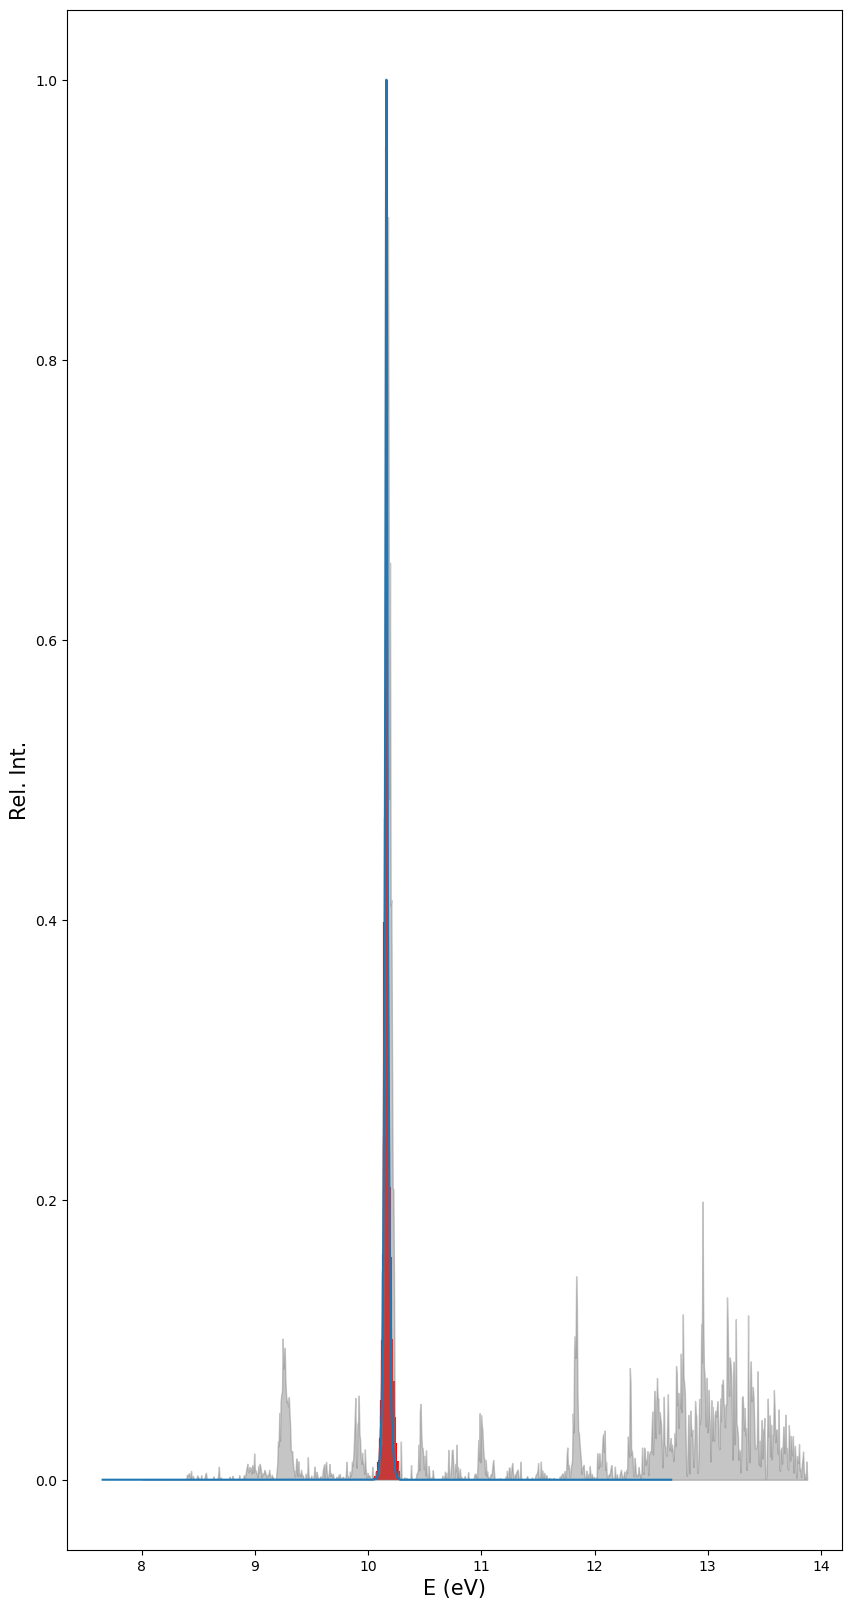

In [32]:
fig2,ax2 = plt.subplots(figsize=(10,20),sharex=True,sharey=True)
# eval2 = evals_temp2[p,o] ; relInt002 = relInt00_temp2[p,o]
maxval = np.max(exp_esp[:,2])
ax2.fill_between(exp_esp[:,0],0,exp_esp[:,2]/maxval,color="gray",alpha=0.45)
maxval = np.max(relInt00)
# maxval2 = np.max(relInt002[:,:,:,:,:,:])
# maxval = max(maxval,maxval2)
ax2.vlines(evals00*27.2114,0,relInt00/maxval,zorder=-10,color="red")

energies = (evals00*27.2114).flatten()
intensities = relInt00.flatten()

emin = energies.min() - 0.05
emax = energies.max() + 0.05
dE = 0.001

E_grid = np.arange(emin, emax, dE)
spectrum = np.zeros_like(E_grid)

for E_k, I_k in zip(energies, intensities):
    idx = np.abs(E_grid - E_k) <= dE
    spectrum[idx] += I_k

bins = np.append(E_grid, E_grid[-1] + dE)

spectrum, _ = np.histogram(
    energies,
    bins=bins,
    weights=intensities
)
sigma_eV=0.005
sigma_bins = sigma_eV/dE
kernel = Gaussian1DKernel(sigma_bins)
spectrum_conv = convolve(spectrum, kernel, normalize_kernel=True, boundary='extend')

spectrum_conv /= np.max(spectrum_conv)
ax2.plot(E_grid,spectrum_conv)

# ax2.set_title("Tvib = "+str(Tvib)+" K ; Trot = "+str(Trot)+" K",fontsize=10)
# ax2.set_xlim(10,10.3)
ax2.set_xlabel("E (eV)",fontsize=15)
ax2.set_ylabel("Rel. Int.",fontsize=15)

### Spectra convolution

In [33]:
vPH = 10 ; vPHM = 10 ; JPH = 20 ; JPHM = 20 ; DJmax = 1.5
eval,relInt = intT_sep(PHJener,PHMGSJener,dysmat_N_C1,PHvibs,PHMGSvibs,mask,1000,300,ZPEPH,ZPEPHMGS,PHGSEtotal,PHMGSEtotal,
                        DJmax,vPH,vPHM,JPH,JPHM,nOmPH,nOmPHGS,index_listPH,index_listPHMGS,keyPH,keyPHMGS,coefPH,coefPHMGS)

energies = (eval*27.2114).flatten()
intensities = relInt.flatten()
emin = energies.min() - 0.05
emax = energies.max() + 0.05
emin = 10.0
emax = 10.3
dE = 0.0005

E_grid = np.arange(emin, emax, dE)
spectrum = np.zeros_like(E_grid)

for E_k, I_k in zip(energies, intensities):
    idx = np.abs(E_grid - E_k) <= dE
    spectrum[idx] += I_k

bins = np.append(E_grid, E_grid[-1] + dE)

spectrum, _ = np.histogram(
    energies,
    bins=bins,
    weights=intensities
)
sigma_eV=0.005
sigma_bins = sigma_eV/dE
kernel = Gaussian1DKernel(sigma_bins)
spectrum_conv = convolve(spectrum, kernel, normalize_kernel=True, boundary='extend')

spectrum_conv /= np.max(spectrum_conv)

[-1.5, -0.5, 0.5, 1.5]


KeyboardInterrupt: 

(10.0, 10.3)

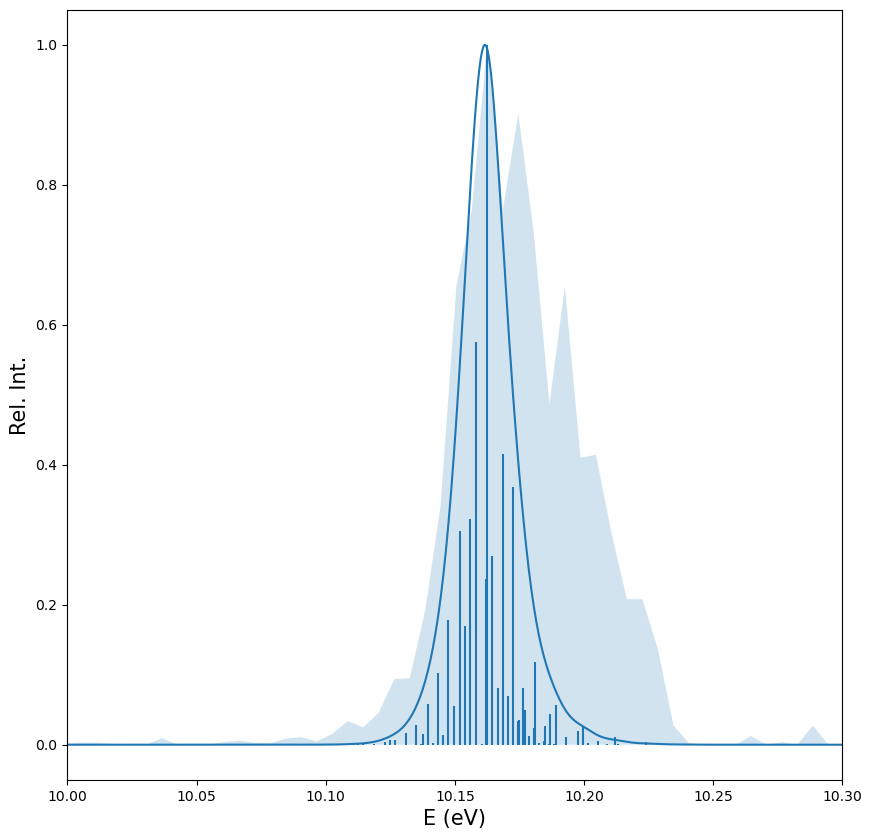

In [ ]:
fig,ax=plt.subplots(figsize=(10,10))
ax.plot(E_grid,spectrum_conv)
maxval = spectrum.max()
ax.vlines(E_grid,0,spectrum/maxval)
# maxval=np.max(intensities)
# ax.vlines(energies,0,intensities/maxval,color="red")
maxval = np.max(exp_esp[:,2])
ax.fill_between(exp_esp[:,0], 0, exp_esp[:,2]/maxval, alpha=0.2)
ax.set_xlabel("E (eV)",fontsize=15)
ax.set_ylabel("Rel. Int.",fontsize=15)
ax.set_xlim(10,10.3)

In [29]:
def lorentzian(x,a,x0):
    return (1/np.pi)*((0.5*a)/((x-x0)**2+(0.5*a)**2))

def process_spectrum(eval,relInt,nvPH,nvPHM,nJPH,nJPHM,nOPH,nOPHM,amp,sttdev):
    emin,emax = np.min(eval)-0.05,np.max(eval)+0.05
    npoints = 5000
    de = (emax-emin)/npoints
    x = np.zeros((nvPH,nvPHM,nJPH,nJPHM,nOPH,nOPHM,npoints))
    y = np.zeros((nvPH,nvPHM,nJPH,nJPHM,nOPH,nOPHM,npoints))
    for i in range(nvPH):
        for j in range(nvPHM):
            for k in range(nJPH):
                for l in range(nJPHM):
                    for m in range(nOPH):
                        for n in range(nOPHM):
                            ept = eval[i,j,k,l,m,n]
                            max_intensity = lorentzian(ept,amp,ept)
                            for o in range(npoints):
                                x[i,j,k,l,m,n,o] = emin+o*de if abs(emin+o*de-ept) >= 0.005 else ept
                                y[i,j,k,l,m,n,o] = (lorentzian(emin+o*de,amp,ept)/max_intensity)*relInt[i,j,k,l,m,n]

    max_y = np.max(y,axis=-1)
    kernel=Gaussian1DKernel(sttdev)
    convoluted=convolve(max_y,kernel,normalize_kernel=True,boundary='extend')
    return x[1],convoluted/np.max(convoluted)*np.max(relInt)


In [30]:
nvPH = nvPHM = 10 ; nJPH = nJPHM = 20 ; nOPH,nOPHM = 3,4 ; amp=1 ; sttdev=0.1
evalConv, relIntConv = process_spectrum(eval,relInt,nvPH,nvPHM,nJPH,nJPHM,nOPH,nOPHM,amp,sttdev)

KeyboardInterrupt: 

In [ ]:
DJmax = 1.5 ; vPH = vPHM = 10 ; JPH = JPHM = 20
evals_temp = [] ; relInt_temp = [] ; tvibl = [] ; trotl = []
evals_temp2 = [] ; relInt_temp2 = [] 
for Tvib in range(200,600,100):
    evrow = []
    relIntrow = []
    for Trot in range(200,600,100):
        if Tvib == 0 or Trot == 0:
            continue
        evals,relInt = intT_sep(PHJener,PHMGSJener,dysmat_N_C1,PHvibs,PHMGSvibs,mask,Tvib,Trot,ZPEPH,ZPEPHMGS,PHGSEtotal,PHMGSEtotal,
                            DJmax,vPH,vPHM,JPH,JPHM,nOmPH,nOmPHGS,index_listPH,index_listPHMGS,keyPH,keyPHMGS,coefPH,coefPHMGS)
        # eval2,relInt2 = int_Coeffs(PHJener,PHMa4SmJener,dysmat_N_C2,PHvibs,PHMa4Smvibs,mask,T,ZPEPH,ZPEPHMa4Sm,PHGSEtotal,PHMa4Etotal,
        #                     DJmax,vPH,vPHM,JPH,JPHM,nOmPH,nOmPHa4Sm,index_listPH,index_listPHMa4Sm,keyPH,keyPHMa4Sm,coefPH,coefPHMa4Sm)
        evrow.append(evals)
        relIntrow.append(relInt)
        trotl.append(Trot)

    evals_temp.append(evrow)
    relInt_temp.append(relInt)
        # evals_temp2.append(eval2)
        # relInt_temp2.append(relInt2)
    tvibl.append(Tvib)
# temps = [800]
if len(temps) == 1:
    eval,relInt = int_Coeffs(PHJener,PHMGSJener,dysmat_N_C1,PHvibs,PHMGSvibs,mask,temps[0],ZPEPH,ZPEPHMGS,PHGSEtotal,PHMGSEtotal,
                        DJmax,vPH,vPHM,JPH,JPHM,nOmPH,nOmPHGS,index_listPH,index_listPHMGS,keyPH,keyPHMGS,coefPH,coefPHMGS)
    # eval2,relInt2 = int_Coeffs(PHJener,PHMa4SmJener,dysmat_N_C2,PHvibs,PHMa4Smvibs,mask,temps[0],ZPEPH,ZPEPHMa4Sm,PHGSEtotal,PHMa4Etotal,
    #                     DJmax,vPH,vPHM,JPH,JPHM,nOmPH,nOmPHa4Sm,index_listPH,index_listPHMa4Sm,keyPH,keyPHMa4Sm,coefPH,coefPHMa4Sm)
    fig2,ax2 = plt.subplots(figsize=(8,8),sharex=True,sharey=True)
    
    maxval=np.max(exp_sharc[:,-1])
    # ax2.plot(exp_sharc[:,0],exp_sharc[:,-1]/maxval,color="purple",label="SHARC Spectrum")
    maxval = np.max(relInt[:,:,:,:,:,:])
    # maxval2 = np.max(relInt2[:,:,:,:,:,:])
    # maxval = max(maxval,maxval2)

    count=0

    for i in range(vPH):
        for j in range(vPHM):
            for k in range(JPH):
                for l in range(JPHM):
                    for m in range(3):
                        for n in range(4):
                            Jival=index_listPH[i,k,m,1]
                            Jfval=index_listPHMGS[j,l,n,1]
                            if (Jfval-Jival) == -2.5:
                                ax2.vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,ls="--",color="crimson")
                                # ax2.vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,ls="--",color="deeppink")
                            if (Jfval-Jival) == -1.5:
                                ax2.vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,ls="-.",color="red")
                                # ax2.vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,ls="-.",color="deeppink")
                            elif (Jfval-Jival) == -0.5:
                                ax2.vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,ls=":",color="green")
                                # ax2.vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,ls=":",color="olivedrab")
                            elif (Jfval-Jival) == 0.5:
                                ax2.vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,color="blue")
                                # ax2.vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,color="yellow")
                            elif (Jfval-Jival) == 1.5:
                                ax2.vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,color="orange")
                                # ax2.vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,color="brown")
                            elif (Jfval-Jival) == 2.5:
                                ax2.vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,ls="--",color="darkorange")
                                # ax2.vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,color="brown")
                            else:
                                ax2.vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,ls="--",color="black")
                                # ax2.vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,color="black")
    
    maxval = np.max(exp_esp[:,2])
    ax2.fill_between(exp_esp[:,0],0,exp_esp[:,2]/maxval,color="black",alpha=0.35)#,label="Exp. Spectrum")
    ax2.plot(exp_esp[:,0],exp_esp[:,2]/maxval,color="black")

    # ax2.vlines(100,0,100,color="red",label="P")
    # ax2.vlines(100,0,100,color="green",label="Q")
    # ax2.vlines(100,0,100,color="blue",label="R")
    # ax2.vlines(100,0,100,color="deeppink",label="P")
    # ax2.vlines(100,0,100,color="olivedrab",label="Q")
    # ax2.vlines(100,0,100,color="indigo",label="R")

    ax2.set_title("T = "+str(temps[0])+" K",fontsize=10)
    ax2.set_xlim(10,10.3) ; ax2.set_ylim(-0.05,1.05)
    ax2.legend(frameon=False,fontsize=15,ncol=2)
    ax2.set_xlabel("E (eV)",fontsize=15)
    ax2.set_ylabel("Rel. Int.",fontsize=15)
else:
    fig2,ax2 = plt.subplots(len(temps),1,figsize=(10,20),sharex=True,sharey=True)
    for p,T in enumerate(temps):
        eval = evals_temp[p] ; relInt = relInt_temp[p]
        # eval2 = evals_temp2[p] ; relInt2 = relInt_temp2[p]
        maxval = np.max(exp_esp[:,2])
        ax2[p].fill_between(exp_esp[:,0],0,exp_esp[:,2]/maxval,color="gray",alpha=0.45)
        maxval = np.max(relInt[:,:,:,:,:,:])
        # maxval2 = np.max(relInt2[:,:,:,:,:,:])
        # maxval = max(maxval,maxval2)
        for i in range(vPH):
            for j in range(vPHM):
                for k in range(JPH):
                    less = 0
                    for l in range(JPHM):
                        for m in range(3):
                            for n in range(4):
                                # Jival=index_listPH[i,k,m,1]
                                # Jfval=index_listPHMGS[j,l,n,1]
                                # if abs(Jival-Jfval) < 10:
                                ax2[p].vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,zorder=-10,color="red")
                                # ax2[p].vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,zorder=-10,color="red")
                                    # if (Jfval-Jival) == -1:
                                    #     ax2[p].vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,zorder=-10,color="red")
                                    #     ax2[p].vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,zorder=-10,color="red")
                                    # elif (Jfval-Jival) == 0:
                                    #     ax2[p].vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,zorder=-10,color="green")
                                    #     ax2[p].vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,zorder=-10,color="green")
                                    # elif (Jfval-Jival) == 1:
                                    #     ax2[p].vlines(eval[i,j,k,l,m,n]*27.2114,0,relInt[i,j,k,l,m,n]/maxval,zorder=-10,color="blue")
                                    #     ax2[p].vlines(eval2[i,j,k,l,m,n]*27.2114,0,relInt2[i,j,k,l,m,n]/maxval,zorder=-10,color="blue")
        
        energies = (eval*27.2114).flatten()
        intensities = relInt.flatten()
        emin = energies.min() - 0.05
        emax = energies.max() + 0.05
        dE = 0.001

        E_grid = np.arange(emin, emax, dE)
        spectrum = np.zeros_like(E_grid)

        for E_k, I_k in zip(energies, intensities):
            idx = np.abs(E_grid - E_k) <= dE
            spectrum[idx] += I_k

        bins = np.append(E_grid, E_grid[-1] + dE)

        spectrum, _ = np.histogram(
            energies,
            bins=bins,
            weights=intensities
        )
        sigma_eV=0.005
        sigma_bins = sigma_eV/dE
        kernel = Gaussian1DKernel(sigma_bins)
        spectrum_conv = convolve(spectrum, kernel, normalize_kernel=True, boundary='extend')

        spectrum_conv /= np.max(spectrum_conv)
        ax2[p].plot(E_grid,spectrum_conv)

        ax2[p].set_title("T = "+str(T)+" K",fontsize=10)
        ax2[p].set_xlim(10,10.3)
    ax2[-1].set_xlabel("E (eV)",fontsize=15)
    ax2[-1].set_ylabel("Rel. Int.",fontsize=15)
    
# fig2.savefig("phgs_phmgs_comp.png",transparent=True,dpi=300)